# 02 - Exploratory Data Analysis (EDA)

**Customer Churn Prediction**, AAI-510, Group 6

This notebook explores how each feature relates to churn, using both graphical and
non-graphical summaries. A key goal is to **validate the three documented churn drivers**
from the dataset author:

1. short tenure (under 12 months) raises churn,
2. high monthly charges (over 100) raise churn,
3. a month-to-month contract raises churn.

Each chart is followed by a short interpretation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("../data/synthetic_customer_churn_100k.csv")

# Numeric 1/0 churn flag for rates and correlations
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)
print(f"Loaded {df.shape[0]:,} rows. Overall churn rate: {df['ChurnFlag'].mean():.1%}")

Loaded 100,000 rows. Overall churn rate: 33.1%


## Target distribution

First, the overall split between churned and retained customers.


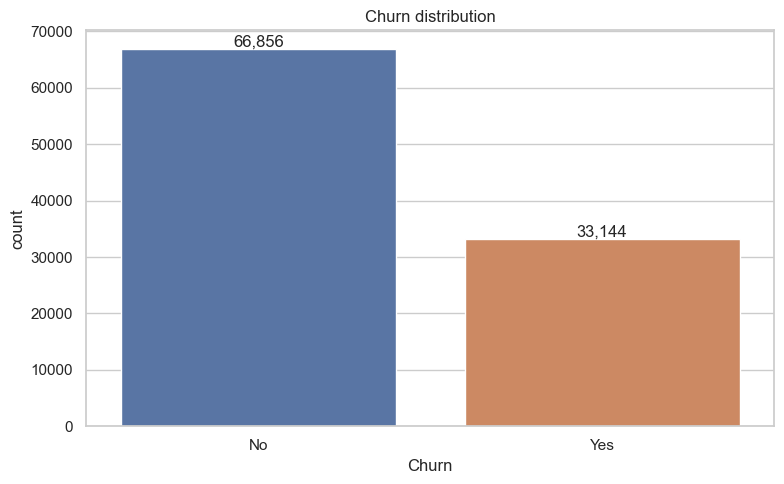

In [2]:
ax = sns.countplot(data=df, x="Churn", order=["No", "Yes"], hue="Churn", legend=False)
ax.set_title("Churn distribution")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Inference.** Roughly one in three customers churns. The classes are imbalanced but not
severely, so standard classifiers with class weighting should work without aggressive
resampling.


## Distributions of the numeric features

We look at the shape of each numeric feature to spot skew or unusual values.


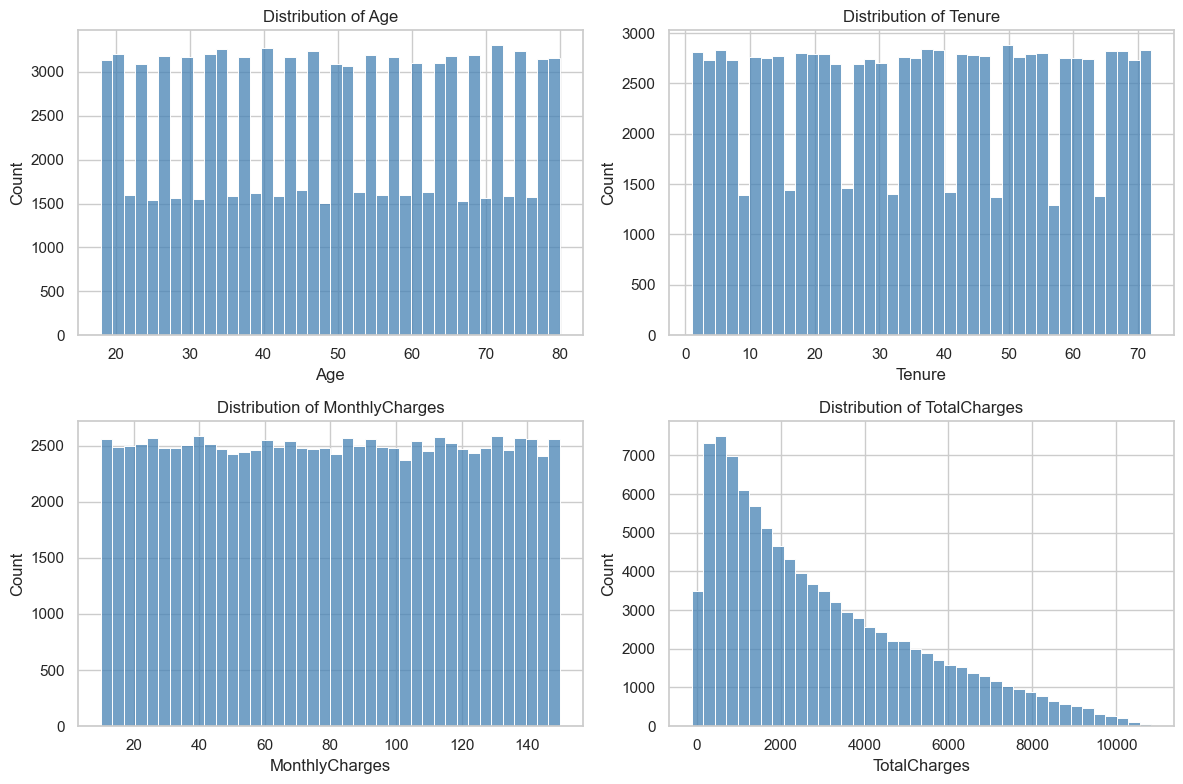

In [3]:
num_cols = ["Age", "Tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], bins=40, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

**Inference.** Age and Tenure are fairly uniform, consistent with synthetic generation.
MonthlyCharges spans roughly 10 to 150. TotalCharges is right-skewed because it is the
product of tenure and monthly charge, so most customers sit at lower totals with a long
tail of high-value, long-tenure customers.


## Numeric features versus churn

We compare the distribution of each numeric feature for churned and retained customers.


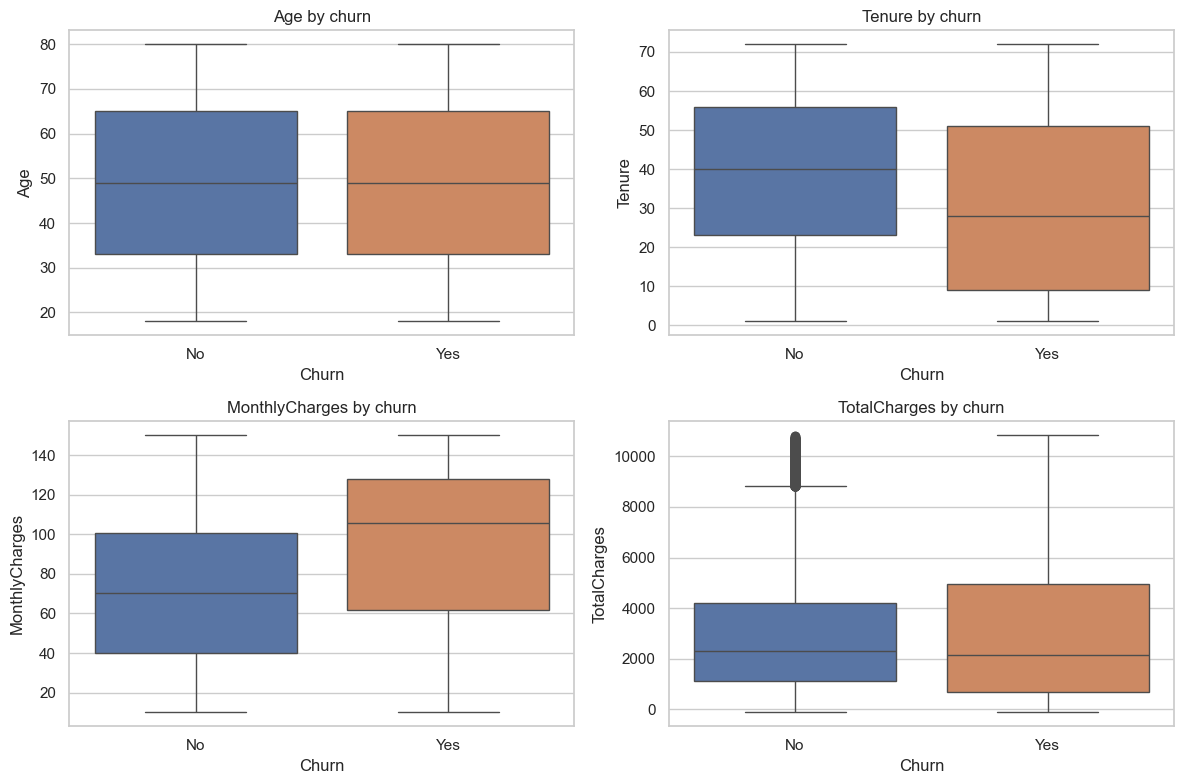

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, x="Churn", y=col, order=["No", "Yes"], hue="Churn",
                legend=False, ax=ax)
    ax.set_title(f"{col} by churn")
plt.tight_layout()
plt.show()

**Inference.** Churned customers tend to have **shorter tenure** and **higher monthly
charges**, while Age shows little separation. TotalCharges is lower for churners, which is
expected since they leave earlier and therefore accumulate less spend. This already supports
two of the three documented churn drivers.


## Churn rate by categorical feature

We compute the churn rate within each category. A flat line would mean the feature carries
no signal; large differences mean the feature matters.


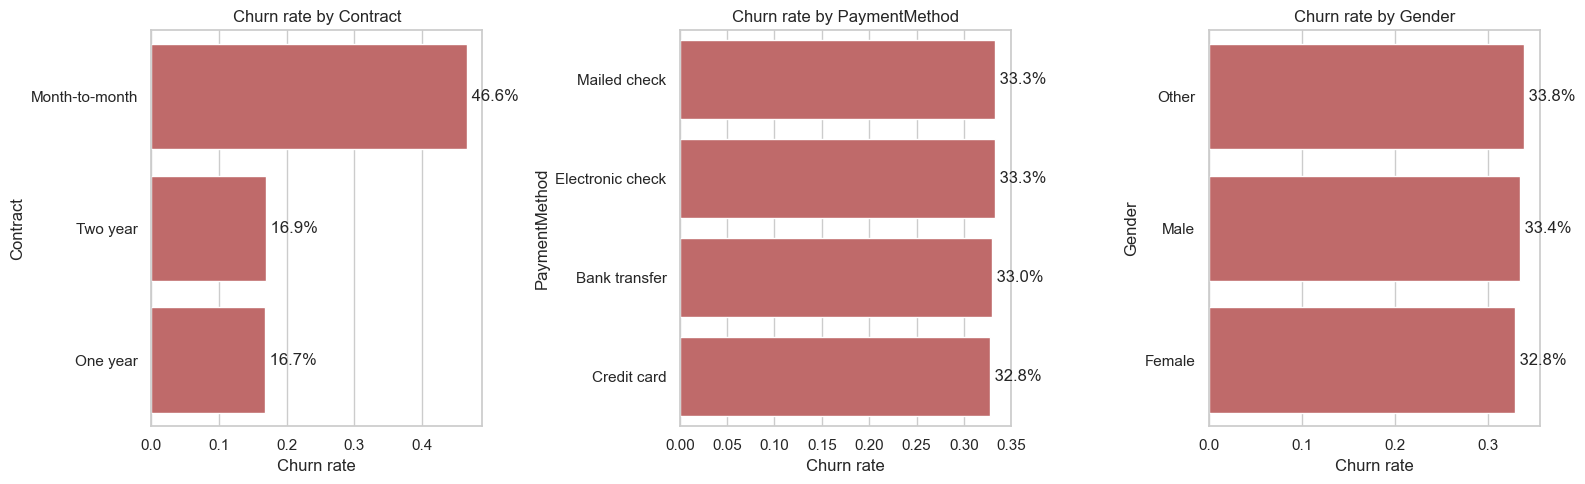

In [5]:
cat_cols = ["Contract", "PaymentMethod", "Gender"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, cat_cols):
    rates = df.groupby(col)["ChurnFlag"].mean().sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, ax=ax, color="indianred")
    ax.set_title(f"Churn rate by {col}")
    ax.set_xlabel("Churn rate")
    for i, v in enumerate(rates.values):
        ax.text(v, i, f" {v:.1%}", va="center")
plt.tight_layout()
plt.show()

**Inference.** **Contract** is the strongest categorical driver: month-to-month customers
churn far more often than one or two year customers, who are locked in. PaymentMethod shows
milder differences, and Gender shows essentially no difference, so Gender is unlikely to be
a useful predictor.


## Validating the three documented churn drivers

We test the author's stated rules directly by comparing churn rates above and below each
threshold.


In [6]:
short = df["Tenure"] < 12
high = df["MonthlyCharges"] > 100
m2m = df["Contract"] == "Month-to-month"

print("Hypothesis 1: short tenure (<12 months) raises churn")
print(f"  tenure <12 : {df.loc[short, 'ChurnFlag'].mean():.1%}")
print(f"  tenure >=12: {df.loc[~short, 'ChurnFlag'].mean():.1%}\n")

print("Hypothesis 2: high monthly charges (>100) raise churn")
print(f"  charges >100 : {df.loc[high, 'ChurnFlag'].mean():.1%}")
print(f"  charges <=100: {df.loc[~high, 'ChurnFlag'].mean():.1%}\n")

print("Hypothesis 3: month-to-month contract raises churn")
print(f"  month-to-month: {df.loc[m2m, 'ChurnFlag'].mean():.1%}")
print(f"  longer term   : {df.loc[~m2m, 'ChurnFlag'].mean():.1%}")

Hypothesis 1: short tenure (<12 months) raises churn
  tenure <12 : 67.4%
  tenure >=12: 27.0%

Hypothesis 2: high monthly charges (>100) raise churn
  charges >100 : 52.4%
  charges <=100: 22.4%

Hypothesis 3: month-to-month contract raises churn
  month-to-month: 46.6%
  longer term   : 16.8%


**Inference.** All three documented drivers are confirmed in the data. Each condition
(short tenure, high monthly charges, month-to-month contract) is associated with a clearly
higher churn rate. These three signals should become strong features for the model, and we
will engineer explicit flags for them in the next notebook.


## Correlation heatmap

Finally, a correlation matrix of the numeric features and the churn flag to quantify the
linear relationships seen above.


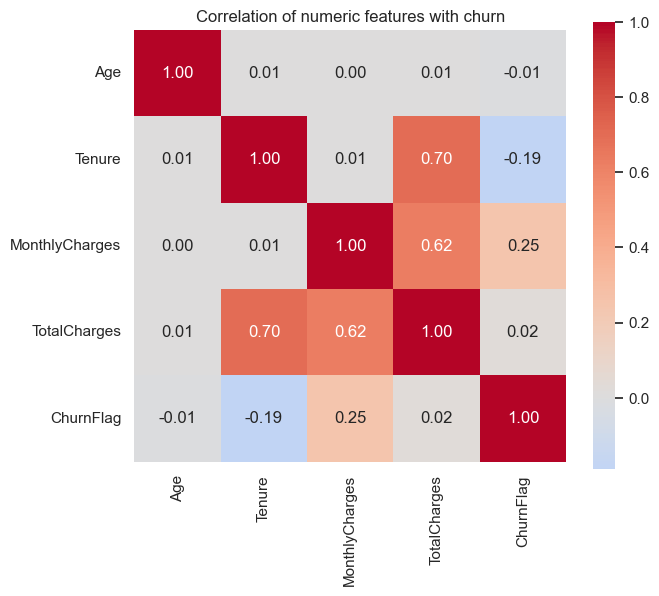

In [7]:
corr = df[num_cols + ["ChurnFlag"]].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation of numeric features with churn")
plt.tight_layout()
plt.show()

### EDA summary and actionable insight

- Churn is driven mainly by **contract type, tenure, and monthly charges**, exactly the
  drivers the dataset documents. Tenure correlates negatively with churn, and monthly
  charges correlate positively.
- **Gender carries no signal** and can likely be dropped or kept with minimal impact.
- TotalCharges is highly correlated with tenure and monthly charges (it is derived from
  them), so we should watch for redundancy during feature selection.
- **Business takeaway:** customers who are new, on month-to-month plans, and paying high
  monthly charges are the highest churn risk. Retention offers (contract incentives,
  loyalty discounts) should target this segment. The next notebook turns these findings into
  engineered features.
